## Divide y Venceras: Multiplicacion de Matrices cuadraticas

In [1]:
import numpy as np

In [4]:
a = np.random.randint(10, size=(4,4))
b = np.random.randint(10, size=(4,4))

print(a)
print(b)

[[6 7 6 6]
 [7 7 9 4]
 [5 7 6 9]
 [9 4 9 1]]
[[3 8 2 7]
 [9 6 7 7]
 [5 8 8 1]
 [3 3 3 2]]


Tenemos tres formas de obtener la multipicacion de matrices cuadraticas:

1. Utilizando la funcion np.matmul()
2. Creando un algoritmo con la solucion clasica
3. Creando un algoritmo recursivo DyC a partir de la solucion clasica

### (1) Utilizando la funcion **np.matmul()** *texto en cursiva*

In [5]:
c = np.matmul(a,b)

In [6]:
print(c)

[[129 156 127 109]
 [141 182 147 115]
 [135 157 134 108]
 [111 171 121 102]]


### (2) Creando un algoritmo con la solución clásica

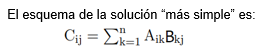

In [8]:
def matmul(a,b):
  aFil, aCol = a.shape
  bFil, bCol = b.shape

  #Ambas matrices no son cuadraticas, pq solo multiplicaremos matrices cuadraticas
  if aCol != bFil:
    return None

  c = np.zeros((aFil,bCol))

  for i in range(aFil):
    for j in range(bCol):
      temp = 0
      #El k va de 1 a n, donde n es la cantidad de col de a
      for k in range(aCol):
        temp += a[i,k] * b[k,j]

      c[i,j] = temp

  return c

In [9]:
d = matmul(a,b)
print(d)

[[129. 156. 127. 109.]
 [141. 182. 147. 115.]
 [135. 157. 134. 108.]
 [111. 171. 121. 102.]]


In [11]:
matmul(a,b) == np.matmul(a,b)

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [13]:
assert matmul(a,b).all() == np.matmul(a,b).all()

## (3) Creando un algoritmo recursivo DyC a partir de la solución clásica

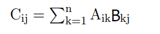

In [15]:
'''
Parametros
a y b las matrices a multiplicar
c es la matriz que contiene el resultado
Para la matriz a, requerimos la fila inicial, sera el i y el tamaño de la matriz a en la variable ii
Para la matriz b, requerimos la fila inicial, sera el j y el tamaño de la matriz b en la variable jj
'''

def matmul_r(a,b,c,i,ii,j,jj):
  #Este calculo solo se realiza si estamos en la misma fila y columna
  if i == ii:
    #Paso (3)Combinar = las operaciones que llevan al resultado final
    temp=0
    for k in range(len(a)):
      temp += a[i,k] * b[k,j]

    #Se actualiza cada indice de c[i,j] con el respectivo producto de a[i,k] * b[k,j]
    c[i,j] = temp
  else:
    #Paso (1) Dividir: ambas matrices a y b las dividimos en 2, entonces tenemos 4 subpartes o subproblemas
    #La mitad de la matriz a
    imid = (i+ii) // 2
    #La mitad de la matriz b
    jmid = (j+jj) // 2

    #Paso (2) Conquistar = EJECUTAR la recursividad en cada subproblema - para cada matriz, del inicio a la mitad y de la mitad al final
    # Calcular de la 1ra mitad de la matriz a con la 1ra mitad de la matriz b
    matmul_r(a,b,c,i,imid,j,jmid)
    # Calcular de la 2da mitad de la matriz a con la 1ra mitad de la matriz b
    matmul_r(a,b,c,imid+1, ii,j,jmid)
    # Calcular de la 1ra mitad de la matriz a con la 2da mitad de la matriz b
    matmul_r(a,b,c,i, imid,jmid+1,jj)
    # Calcular de la 2da mitad de la matriz a con la 2da mitad de la matriz b
    matmul_r(a,b,c,imid+1, ii,jmid+1,jj)

    
print(d)


[[129. 156. 127. 109.]
 [141. 182. 147. 115.]
 [135. 157. 134. 108.]
 [111. 171. 121. 102.]]


In [16]:
#Matriz que recibira el resultado de a x b
c1 = np.zeros((4,4))
print(c1)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [17]:
matmul_r(a,b,c1,0,len(a)-1,0,len(b)-1)
print(c1)

[[129. 156. 127. 109.]
 [141. 182. 147. 115.]
 [135. 157. 134. 108.]
 [111. 171. 121. 102.]]


Probemos el algoritmo matmul_r para un par de matrices de 8x8

In [19]:
a1 = np.random.randint(10, size=(8,8))
b1 = np.random.randint(10, size=(8,8))
c1_res = np.zeros((8,8))
print(a1)
print(b1)
print(c1_res)

[[5 4 1 0 7 1 5 7]
 [1 2 0 7 8 8 8 0]
 [2 2 2 0 0 4 6 3]
 [0 1 8 3 9 1 0 6]
 [5 9 4 1 2 9 6 0]
 [8 3 9 1 0 0 3 8]
 [8 4 3 3 5 3 1 2]
 [1 8 2 9 0 2 6 9]]
[[7 2 8 6 0 6 8 0]
 [1 6 7 1 4 8 8 1]
 [2 0 0 6 8 3 2 9]
 [9 2 9 4 5 5 4 7]
 [7 9 9 6 3 5 7 1]
 [2 0 3 2 3 8 3 9]
 [2 3 9 7 5 3 2 2]
 [5 9 5 4 3 3 0 8]]
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [20]:
#Funcion recursiva
matmul_r(a1,b1,c1_res,0,len(a1)-1,0,len(b1)-1)
print(c1_res)

[[137. 175. 214. 147.  94. 144. 136.  95.]
 [160. 124. 253. 156. 131. 185. 148. 147.]
 [ 55.  61. 111.  88.  75.  93.  60.  92.]
 [139. 147. 148. 141. 131. 118. 102. 160.]
 [105. 102. 211. 139. 136. 219. 177. 147.]
 [132. 117. 161. 162. 128. 137. 116. 161.]
 [146. 112. 192. 133.  90. 162. 160. 102.]
 [161. 167. 250. 144. 156. 182. 130. 191.]]


In [21]:
#Funcion clasica
c1_res_1 = matmul(a1,b1)
print(c1_res_1)

[[137. 175. 214. 147.  94. 144. 136.  95.]
 [160. 124. 253. 156. 131. 185. 148. 147.]
 [ 55.  61. 111.  88.  75.  93.  60.  92.]
 [139. 147. 148. 141. 131. 118. 102. 160.]
 [105. 102. 211. 139. 136. 219. 177. 147.]
 [132. 117. 161. 162. 128. 137. 116. 161.]
 [146. 112. 192. 133.  90. 162. 160. 102.]
 [161. 167. 250. 144. 156. 182. 130. 191.]]


In [22]:
#Con la funcion de Numpy
c1_res_2 = np.matmul(a1,b1)
print(c1_res_2)


[[137 175 214 147  94 144 136  95]
 [160 124 253 156 131 185 148 147]
 [ 55  61 111  88  75  93  60  92]
 [139 147 148 141 131 118 102 160]
 [105 102 211 139 136 219 177 147]
 [132 117 161 162 128 137 116 161]
 [146 112 192 133  90 162 160 102]
 [161 167 250 144 156 182 130 191]]
